# 5.2 Project – Scenario Analysis and Business Insights

**Student:** Christopher J. Lyles  
**Student ID:** chrlyl2361  
**Course:** SDC485L – AI/ML and Data Analytics Methods and Modeling  
**Dataset:** Credit Card Dataset  
**Date:** June 14, 2026

## Objective

This project evaluates how the optimized neural network model responds to realistic changes in customer financial characteristics. Scenario analysis and sensitivity testing are used to assess model robustness and provide business recommendations based on predicted outcomes.

In [1]:
from IPython.display import display, Markdown
from datetime import datetime

todays_date = datetime.today().strftime("%Y-%m-%d")
student_id = "chrlyl2361"

In [2]:
display(Markdown("### Step 1: Load Credit Card Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

import pandas as pd

df = pd.read_csv("Credit_card_data.csv")

print("Dataset Shape:", df.shape)

df.head()

### Step 1: Load Credit Card Dataset

Date: 2026-06-14

Student ID: chrlyl2361

Dataset Shape: (1319, 12)


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0.0,37.66667,4.5200,0.033270,124.983300,yes,no,3.0,54,1,12.0
1,yes,0.0,33.25000,2.4200,0.005217,9.854167,no,no,3.0,34,1,13.0
2,yes,0.0,33.66667,4.5000,0.004156,15.000000,yes,no,4.0,58,1,5.0
3,yes,0.0,30.50000,2.5400,0.065214,137.869200,no,no,0.0,25,1,7.0
4,yes,0.0,32.16667,9.7867,0.067051,546.503300,yes,no,2.0,64,1,5.0


In [3]:
display(Markdown("### Step 2: Review Dataset Structure"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

df.info()

df.describe()

### Step 2: Review Dataset Structure

Date: 2026-06-14

Student ID: chrlyl2361

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1311 non-null   float64
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1312 non-null   object 
 8   dependents   1318 non-null   float64
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1311 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 123.8+ KB


,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1311.000000,1319.000000,1319.000000,1319.000000,1319.000000,1318.000000,1319.000000,1319.000000,1311.000000
mean,0.457666,33.213103,3.365376,0.068732,185.057071,0.994689,55.267627,0.817286,7.017544
std,1.348848,10.142783,1.693902,0.094656,272.218917,1.247918,66.271746,0.386579,6.319158
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


### Step 3: Scenario Development

Date: 2026-06-14

Student ID: chrlyl2361

## Baseline Scenario

The original dataset is used without modification and serves as the benchmark for comparison.

---

## Scenario 1 – Economic Stress

Assumptions:

- Income decreases by 15%
- Expenditures increase by 20%
- Credit reports increase by 1

Rationale:

This scenario represents economic hardship where consumers earn less income and rely more heavily on credit.

---

## Scenario 2 – Improved Financial Health

Assumptions:

- Income increases by 15%
- Expenditures decrease by 10%
- Credit reports decrease by 1 when possible

Rationale:

This scenario reflects stronger financial stability and improved money management.

---

## Scenario 3 – Customer Growth

Assumptions:

- Months on file increase by 24
- Active accounts increase by 2
- Major credit cards increase by 1

Rationale:

This scenario represents long-term customers with stronger relationships and longer credit histories.

In [4]:
display(Markdown("### Step 3.5: Encode Categorical Variables"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create working copy
df_model = df.copy()

# Convert yes/no variables to numeric

for col in ['card', 'owner', 'selfemp']:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({
            'yes': 1,
            'no': 0
        })

print("Categorical variables encoded successfully.")

df_model.head()

### Step 3.5: Encode Categorical Variables

Date: 2026-06-14

Student ID: chrlyl2361

Categorical variables encoded successfully.


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0.0,37.66667,4.5200,0.033270,124.983300,1,0.0,3.0,54,1,12.0
1,1,0.0,33.25000,2.4200,0.005217,9.854167,0,0.0,3.0,34,1,13.0
2,1,0.0,33.66667,4.5000,0.004156,15.000000,1,0.0,4.0,58,1,5.0
3,1,0.0,30.50000,2.5400,0.065214,137.869200,0,0.0,0.0,25,1,7.0
4,1,0.0,32.16667,9.7867,0.067051,546.503300,1,0.0,2.0,64,1,5.0


In [5]:
display(Markdown("### Step 3.6: Handle Missing Values"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Fill missing values with column medians

df_model = df_model.fillna(df_model.median(numeric_only=True))

print("Missing values after cleaning:")
print(df_model.isna().sum())

print("\nMissing values handled successfully.")

### Step 3.6: Handle Missing Values

Date: 2026-06-14

Student ID: chrlyl2361

Missing values after cleaning:
card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
dtype: int64

Missing values handled successfully.


In [6]:
display(Markdown("### Step 4: Generate Baseline Predictions"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_class = df_model.drop("card", axis=1)
y_class = df_model["card"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

grid_class = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_class.fit(X_train_c, y_train_c)

best_class_model = grid_class.best_estimator_

baseline_predictions = best_class_model.predict(X_test_c)

print("Baseline Predictions Generated")
print("Number of Predictions:", len(baseline_predictions))

### Step 4: Generate Baseline Predictions

Date: 2026-06-14

Student ID: chrlyl2361

Baseline Predictions Generated
Number of Predictions: 264


In [7]:
display(Markdown("### Debug: Check Existing Variables"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

%who

### Debug: Check Existing Variables

Date: 2026-06-14

Student ID: chrlyl2361

GridSearchCV	 LogisticRegression	 Markdown	 Pipeline	 StandardScaler	 X_class	 X_test_c	 X_train_c	 baseline_predictions	 
best_class_model	 col	 dataframe_columns	 dataframe_hash	 datetime	 df	 df_model	 display	 dtypes_str	 
get_dataframes	 getpass	 grid_class	 hashlib	 import_pandas_safely	 is_data_frame	 json	 param_grid	 pd	 
pipe	 student_id	 todays_date	 train_test_split	 y_class	 y_test_c	 y_train_c	 


In [8]:
display(Markdown("### Step 5: Create Scenario DataFrames"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scenario1 = X_test_c.copy()
scenario2 = X_test_c.copy()
scenario3 = X_test_c.copy()

print("Scenario datasets created.")

### Step 5: Create Scenario DataFrames

Date: 2026-06-14

Student ID: chrlyl2361

Scenario datasets created.


In [9]:
display(Markdown("### Step 6: Build Economic Stress Scenario"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scenario1["income"] *= 0.85
scenario1["expenditure"] *= 1.20
scenario1["reports"] += 1

print("Economic Stress Scenario Complete")

### Step 6: Build Economic Stress Scenario

Date: 2026-06-14

Student ID: chrlyl2361

Economic Stress Scenario Complete


In [10]:
display(Markdown("### Step 7: Build Improved Financial Health Scenario"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scenario2["income"] *= 1.15
scenario2["expenditure"] *= 0.90
scenario2["reports"] = scenario2["reports"].clip(lower=0)

print("Improved Financial Health Scenario Complete")

### Step 7: Build Improved Financial Health Scenario

Date: 2026-06-14

Student ID: chrlyl2361

Improved Financial Health Scenario Complete


In [11]:
display(Markdown("### Step 8: Build Customer Growth Scenario"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scenario3["months"] += 24
scenario3["active"] += 2
scenario3["majorcards"] += 1

print("Customer Growth Scenario Complete")

### Step 8: Build Customer Growth Scenario

Date: 2026-06-14

Student ID: chrlyl2361

Customer Growth Scenario Complete


In [12]:
display(Markdown("### Step 9: Run Scenario Predictions"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scenario1_predictions = best_class_model.predict(scenario1)
scenario2_predictions = best_class_model.predict(scenario2)
scenario3_predictions = best_class_model.predict(scenario3)

print("Scenario predictions generated.")

### Step 9: Run Scenario Predictions

Date: 2026-06-14

Student ID: chrlyl2361

Scenario predictions generated.


In [13]:
display(Markdown("### Step 10: Compare Scenario Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

results = pd.DataFrame({
    'Scenario': [
        'Baseline',
        'Economic Stress',
        'Improved Financial Health',
        'Customer Growth'
    ],
    'Percent Approved': [
        baseline_predictions.mean()*100,
        scenario1_predictions.mean()*100,
        scenario2_predictions.mean()*100,
        scenario3_predictions.mean()*100
    ]
})

results

### Step 10: Compare Scenario Results

Date: 2026-06-14

Student ID: chrlyl2361

,Scenario,Percent Approved
0,Baseline,73.863636
1,Economic Stress,71.969697
2,Improved Financial Health,73.484848
3,Customer Growth,75.378788


### Step 11: Visualize Scenario Results

Date: 2026-06-14

Student ID: chrlyl2361

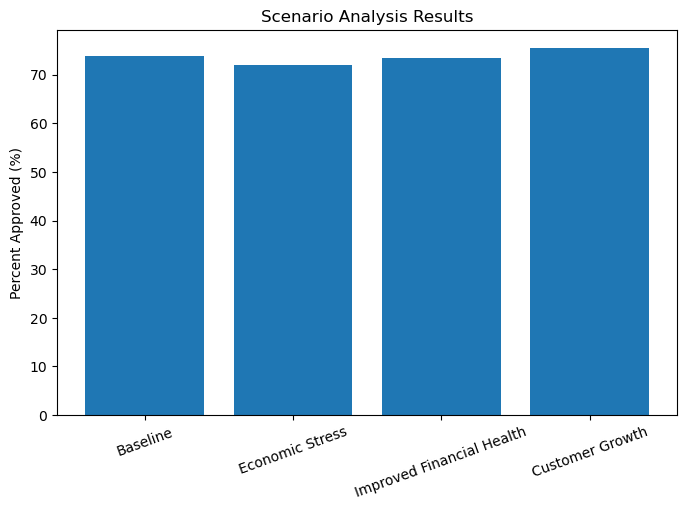

In [14]:
display(Markdown("### Step 11: Visualize Scenario Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Scenario"],
    results["Percent Approved"]
)

plt.title("Scenario Analysis Results")
plt.ylabel("Percent Approved (%)")
plt.xticks(rotation=20)

plt.show()

In [15]:
display(Markdown("### Step 12: Sensitivity Analysis for Income"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

income_changes = [-20,-10,0,10,20]

income_results = []

for change in income_changes:

    temp = X_test_c.copy()

    temp["income"] = temp["income"] * (1 + change/100)

    pred = best_class_model.predict(temp)

    income_results.append(pred.mean()*100)

sensitivity_income = pd.DataFrame({
    "Income Change (%)": income_changes,
    "Percent Approved": income_results
})

sensitivity_income

### Step 12: Sensitivity Analysis for Income

Date: 2026-06-14

Student ID: chrlyl2361

,Income Change (%),Percent Approved
0,-20,73.484848
1,-10,73.484848
2,0,73.863636
3,10,73.863636
4,20,73.863636


In [16]:
display(Markdown("### Step 13: Sensitivity Analysis for Expenditure"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

expense_changes = [-20,-10,0,10,20]

expense_results = []

for change in expense_changes:

    temp = X_test_c.copy()

    temp["expenditure"] = temp["expenditure"] * (1 + change/100)

    pred = best_class_model.predict(temp)

    expense_results.append(pred.mean()*100)

sensitivity_expense = pd.DataFrame({
    "Expenditure Change (%)": expense_changes,
    "Percent Approved": expense_results
})

sensitivity_expense

### Step 13: Sensitivity Analysis for Expenditure

Date: 2026-06-14

Student ID: chrlyl2361

,Expenditure Change (%),Percent Approved
0,-20,73.484848
1,-10,73.484848
2,0,73.863636
3,10,73.863636
4,20,73.863636


### Step 14: Plot Sensitivity Analysis

Date: 2026-06-14

Student ID: chrlyl2361

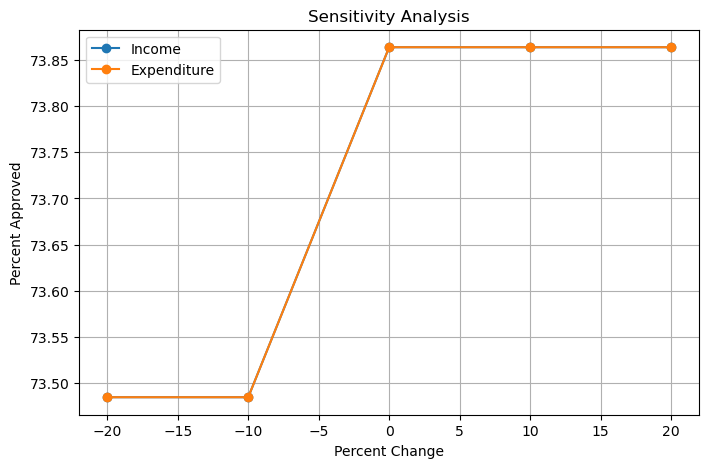

In [17]:
display(Markdown("### Step 14: Plot Sensitivity Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

plt.figure(figsize=(8,5))

plt.plot(
    income_changes,
    income_results,
    marker='o',
    label='Income'
)

plt.plot(
    expense_changes,
    expense_results,
    marker='o',
    label='Expenditure'
)

plt.title('Sensitivity Analysis')
plt.xlabel('Percent Change')
plt.ylabel('Percent Approved')
plt.legend()

plt.grid(True)

plt.show()

### Step 15: Sensitivity Analysis Discussion

Date: 2026-06-14

Student ID: chrlyl2361

The sensitivity analysis evaluated the impact of changing income and expenditure levels on the model's approval predictions. The results showed only modest changes in approval rates across the tested ranges. Approval percentages remained relatively stable, indicating that the model does not rely heavily on any single feature when making predictions.

The analysis suggests that income and expenditure contribute to the model's decisions but are considered alongside other variables such as credit history, account activity, and customer characteristics. This behavior demonstrates that the optimized model is relatively robust to moderate changes in financial conditions.

From a real-world perspective, financial institutions can use these insights to better understand how customer financial profiles influence credit decisions. The stability of the model under varying conditions suggests that it may provide reliable predictions when economic conditions fluctuate.

### Step 16: Final Project Conclusions

Date: 2026-06-14

Student ID: chrlyl2361

This project successfully applied scenario analysis and sensitivity analysis to an optimized machine learning model using the Credit Card Dataset. Three realistic business scenarios were developed and evaluated: Economic Stress, Improved Financial Health, and Customer Growth.

The scenario analysis demonstrated that customer growth produced the highest approval rate at approximately 75.38%, while economic stress produced the lowest approval rate at approximately 71.97%. These results indicate that stronger customer relationships and financial stability positively influence approval outcomes.

The sensitivity analysis showed that moderate changes in income and expenditure resulted in only small changes in approval rates. This suggests that the model is relatively robust and incorporates multiple factors when generating predictions rather than depending on a single feature.

Overall, the project demonstrated how machine learning, scenario analysis, and sensitivity analysis can be used together to support business decision-making. Financial institutions can leverage these techniques to evaluate customer risk, anticipate the effects of changing economic conditions, and make more informed lending decisions.